In [33]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.rcParams.update({'font.size': 16})

## Exploratory Data Analysis

The goal is to demonstrate that it's reasonable to investigate how sensitive MADDPG is to hyperparameters (and environment parameters). That is, under what conditions does it fail to learn swarm behavior?

Some plots we can use are:
- histogram of average rewards
- box plot of rewards and/or DoS/DoA
- scatter plot of average reward, DoS, DoA

A really easy argument to make is: we see good learning behavior in one random seed, but not another.

We can also hypothesize when it may break depending on the "weaknesses" of MADDPG.

Experiments were done with:
```
{
    "dynamics_mode": "Polar",
    "n_p": 3,
    "n_e": 25,
    "pursuer_strategy": "input",
    "escaper_strategy": "input",
    "is_periodic": true,
    "render_traj": true,
    "save_frame": false,

    "m_p": 3.0,
    "m_e": 1.0,
    "size_p": 0.06,
    "size_e": 0.035
}
seed: 42, 43, 44, 500
episodes: 201
episode_length: 200
```

In [34]:
def load_data(file_path, print_info=True):
    data = pl.read_csv(file_path)
    if print_info:
        print(data.glimpse())
    return data


def plot_dos_and_doa(data: pl.DataFrame,
    dos_color='blue', doa_color='green', window_size=10, show=True,
    axes=None, legend=True,
    figsize=(12, 6)):
    """
    Plot DoS and DoA metrics with moving average and standard deviation bands.

    Since their range is between 0 and 1, we can plot them on the same axes
    for easier comparisons.
    
    Args:
        data: Polars DataFrame containing the metrics
        ax: Axes object to plot on (if None, creates new figure)
        window_size: Window size for moving average calculation
    """
    if axes is None:
        fig, axes = plt.subplots(2, 1, figsize=figsize)
    # Get the episode and metric columns
    episode = data['# episode'].to_numpy()
    
    # Plot DoS
    if 'dos' in data.columns:
        dos = data['dos'].to_numpy()
        dos_ma = np.convolve(dos, np.ones(window_size)/window_size, mode='valid')
        dos_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        dos_std = np.array([dos[max(0, i-window_size):i].std() for i in range(window_size, len(dos)+1)])
        
        axes[0].plot(dos_episodes, dos_ma, color=dos_color, linewidth=2, label='Moving Average')
        axes[0].fill_between(dos_episodes, dos_ma - dos_std, dos_ma + dos_std, 
                            alpha=0.3, color=dos_color, label='±1 Std Dev')
        axes[0].scatter(episode, dos, alpha=0.2, s=10, color='gray', label='Raw Data')
        axes[0].set_xlabel('Episode')
        axes[0].set_ylabel('DoS')
        # axes[0].set_title('Degree of Swarming (DoS)')
        if legend:
            axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # Plot DoA
    if 'doa' in data.columns:
        doa = data['doa'].to_numpy()
        doa_ma = np.convolve(doa, np.ones(window_size)/window_size, mode='valid')
        doa_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        doa_std = np.array([doa[max(0, i-window_size):i].std() for i in range(window_size, len(doa)+1)])
        
        axes[1].plot(doa_episodes, doa_ma, color=doa_color, linewidth=2, label='Moving Average')
        axes[1].fill_between(doa_episodes, doa_ma - doa_std, doa_ma + doa_std, 
                            alpha=0.3, color=doa_color, label='±1 Std Dev')
        axes[1].scatter(episode, doa, alpha=0.2, s=10, color='gray', label='Raw Data')
        axes[1].set_xlabel('Episode')
        axes[1].set_ylabel('DoA')
        # axes[1].set_title('Degree of Alignment (DoA)')
        if legend:
            axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if show:
        plt.show()



def plot_rewards(data: pl.DataFrame, num_of_predators=3, window_size=10,
    show=True,
    ax=None, legend=True, figsize=(12, 6)
):
    """
    Plot rewards for each agent with moving average and standard deviation bands.
    
    Args:
        data: Polars DataFrame containing the rewards
        num_of_predators: Number of predator agents in the environment
        window_size: Window size for moving average calculation
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    episode = data['# episode'].to_numpy()
    reward_columns = [col for col in data.columns if col.startswith('reward_')]
    
    # plot predators (first num_of_predators in reward columns)
    for i, reward_col in enumerate(reward_columns[:num_of_predators]):
        rewards = data[reward_col].to_numpy()
        rewards_ma = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
        reward_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        rewards_std = np.array([rewards[max(0, i-window_size):i].std() for i in range(window_size, len(rewards)+1)])
        
        ax.plot(reward_episodes, rewards_ma, linewidth=2, label=f'Predator {i+1}')
        ax.fill_between(reward_episodes, rewards_ma - rewards_std, rewards_ma + rewards_std, 
                        alpha=0.3)
        ax.scatter(episode, rewards, alpha=0.2, s=10, color='gray')

    # plot prey (last reward column)
    if len(reward_columns) > num_of_predators:
        prey_rewards = data[reward_columns[-1]].to_numpy()
        prey_rewards_ma = np.convolve(prey_rewards, np.ones(window_size)/window_size, mode='valid')
        prey_reward_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        prey_rewards_std = np.array([prey_rewards[max(0, i-window_size):i].std() for i in range(window_size, len(prey_rewards)+1)])
        
        ax.plot(prey_reward_episodes, prey_rewards_ma, 'r-', linewidth=2, label='Prey')
        ax.fill_between(prey_reward_episodes, prey_rewards_ma - prey_rewards_std, 
                        prey_rewards_ma + prey_rewards_std, alpha=0.3, color='red')
        ax.scatter(episode, prey_rewards, alpha=0.2, s=10, color='gray')
    
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')
    # ax.set_title('Agent Rewards Over Episodes')
    if legend:
        ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if show:
        plt.show()


def plot_histogram(data: pl.DataFrame,
    column_name: str, ax,
    figsize=(10, 6), show=True):
    """
    Plot a histogram of a specified column from the DataFrame.
    
    Args:
        data: Polars DataFrame containing the data
        column_name: Name of the column to plot
    """
    if column_name in data.columns:
        values = data[column_name].to_numpy()
        ax.hist(values, bins=30, alpha=0.7, color='blue')
        ax.set_xlabel(column_name)
        ax.set_ylabel('Frequency')
        # ax.set_title(f'Histogram of {column_name}')
        ax.grid(True, alpha=0.3)
        if show:
            plt.show()
    else:
        print(f"Column '{column_name}' not found in the DataFrame.")

## MADDPG
There are subtle differences between each run, but they are very minor. Ideally, we would remove the curves and just make a scatter plot to visualize these trends.

The histogram indicates the rewards are following something like a poisson distribution.

Conclusion: The behavior is pretty consistent over multiple random seeds.

DoA is much higher if you reduce the number of prey to 10.

Varying the number of predators and prey did not affect convergence to swarm behavior, which is actually pretty interesting. That sort of can be used to validate our investigation, because that's not quite expected.


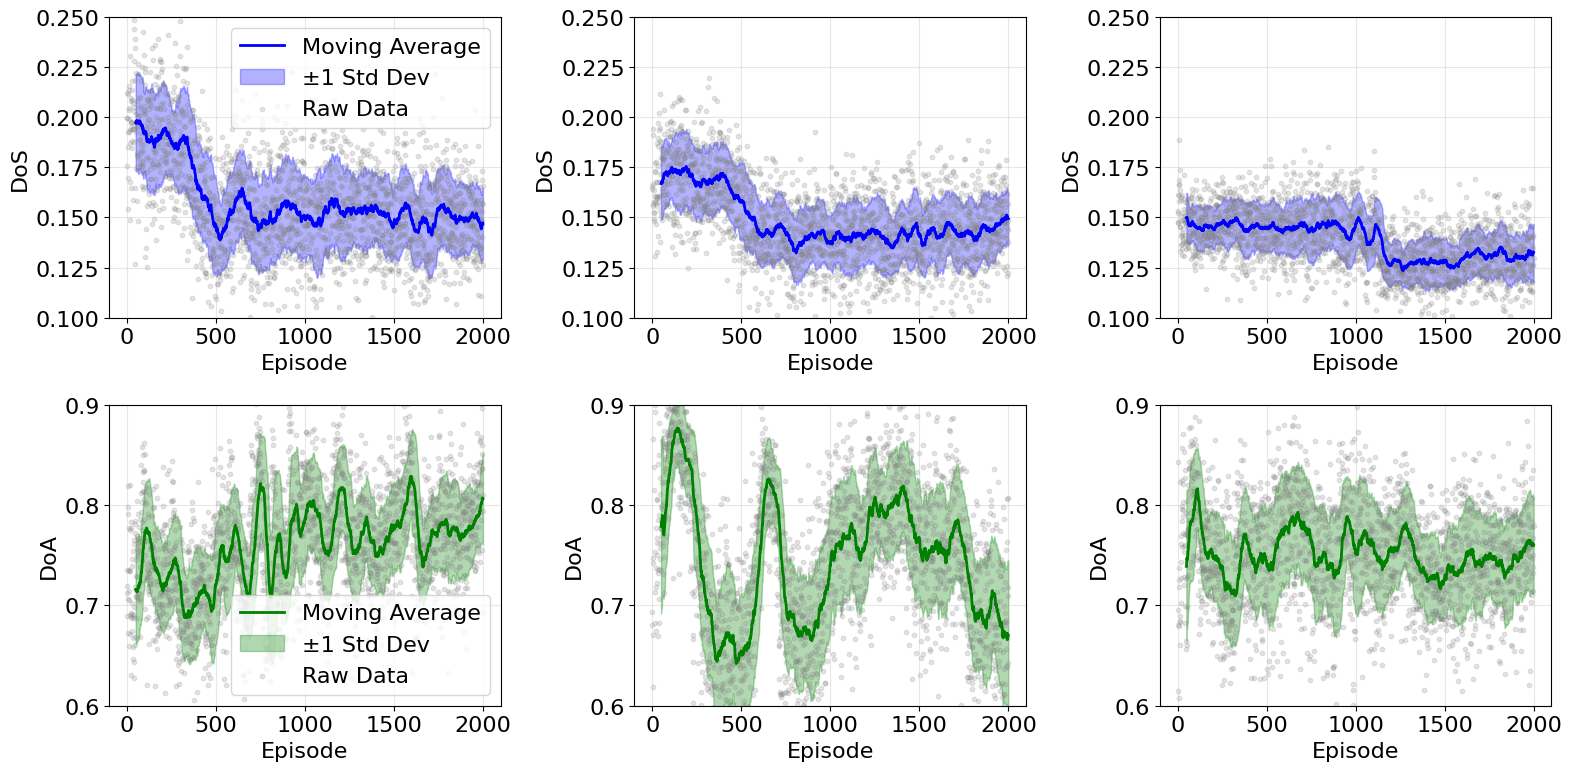

In [ ]:
# with 10 prey and 3 predators
run1 = '../experimental_methods/models/eda02/run13/metrics.csv'
# 15 prey, 3 predators
run2 = '../experimental_methods/models/eda03/run2/metrics.csv' # evaluation video in this one shows predators singling out prey and chasing them around
# this was with 20 prey and 3 predators
run3 = '../experimental_methods/models/eda03/run1/metrics.csv'

figsize = (16, 8)
fig, axes = plt.subplots(2, 3, figsize=figsize)

data = load_data(run1, print_info=False)
data2 = load_data(run2, print_info=False)
data3 = load_data(run3, print_info=False)

plot_dos_and_doa(data, window_size=50, axes=axes[:, 0], show=False, legend=False)
plot_dos_and_doa(data2, window_size=50, axes=axes[:, 1], show=False, legend=False)
plot_dos_and_doa(data3, window_size=50, axes=axes[:, 2], show=False, legend=False)
# align y-axis limits for better comparison
for ax in axes[0, :]:
    ax.set_ylim(0.1, 0.25)
for ax in axes[1, :]:
    ax.set_ylim(0.6, 0.9)
plt.tight_layout()
plt.savefig('dos_doa_comparison.png')
plt.show()

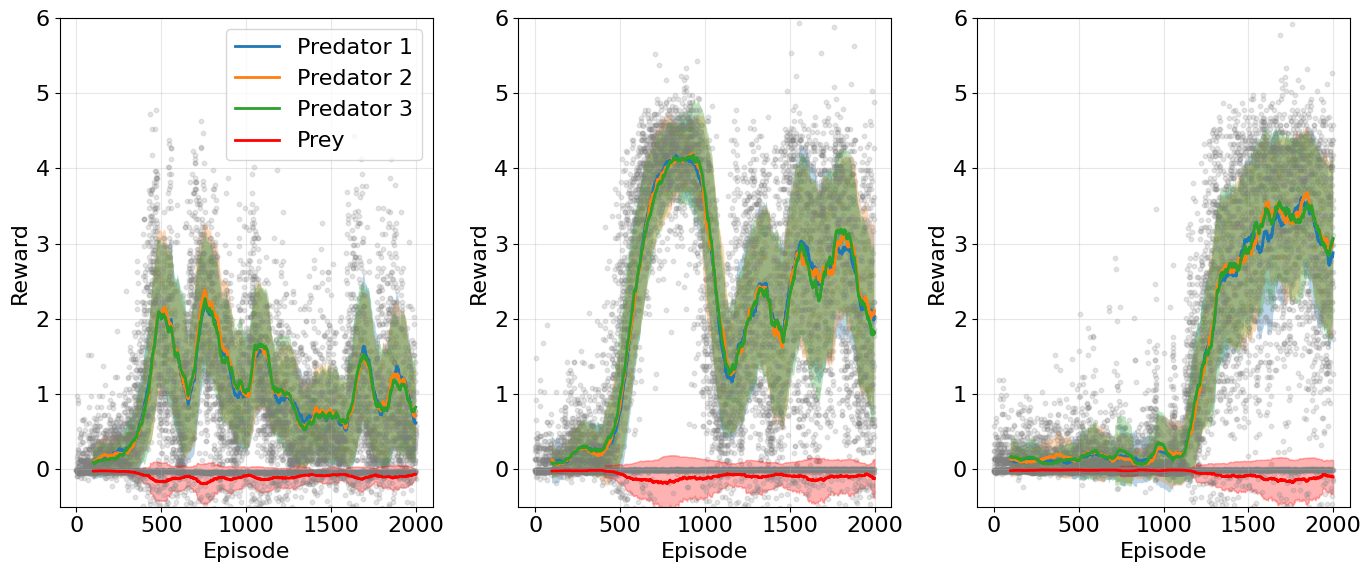

In [36]:
# plotting rewards for each agent
rewards_figsize = (14, 6)
fig, axes = plt.subplots(1, 3, figsize=rewards_figsize)
plot_rewards(data, window_size=100, ax=axes[0], show=False, legend=True, figsize=rewards_figsize)
plot_rewards(data2, window_size=100, ax=axes[1], show=False, legend=False, figsize=rewards_figsize)
plot_rewards(data3, window_size=100, ax=axes[2], show=False, legend=False, figsize=rewards_figsize)

for ax in axes:
    ax.set_xticks([0, 500, 1000, 1500, 2000])
    ax.set_ylim(-0.5, 6)

plt.tight_layout()
plt.savefig('rewards_comparison.png')
plt.show()

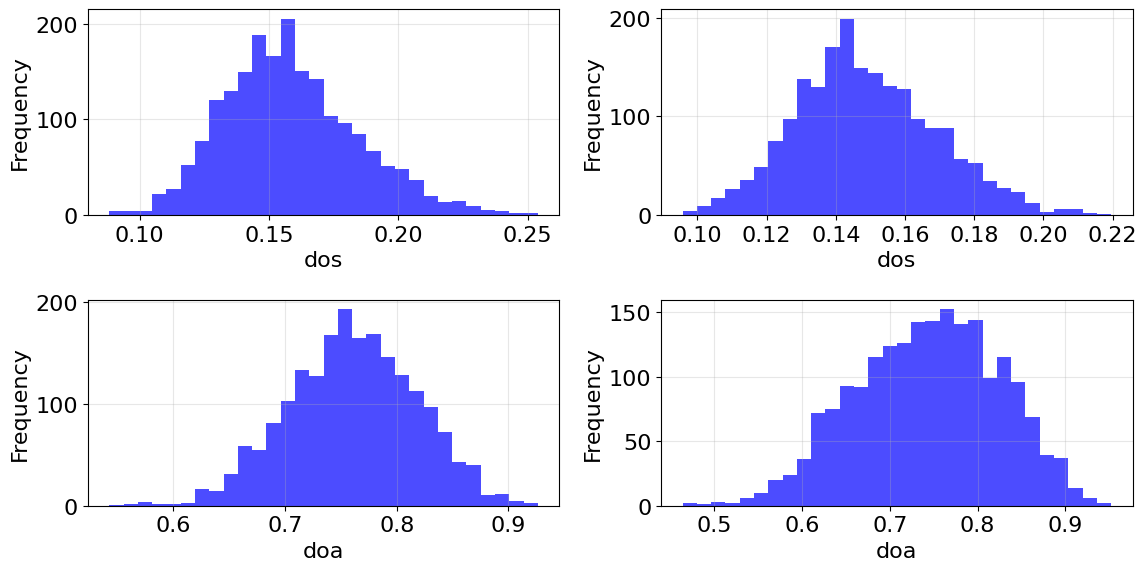

In [37]:
hist_figsize = (12, 6)
fig, axes = plt.subplots(2, 2, figsize=hist_figsize)
plot_histogram(data, column_name='dos', ax=axes[0, 0], show=False)
plot_histogram(data, column_name='doa', ax=axes[1, 0], show=False)
plot_histogram(data2, column_name='dos', ax=axes[0, 1], show=False)
plot_histogram(data2, column_name='doa', ax=axes[1, 1], show=False)
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()